# Importing Required Libraries

In [11]:
import pandas as pd
import json
import ast
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import numpy as np

# Creating Dataset (Converting the results.json obtained from quizapp to csv file)

In [2]:
with open('/content/drive/MyDrive/results.json', 'r') as f:
    data = json.load(f)

df = pd.json_normalize(data)

if '_id.$oid' in df.columns:
    df.rename(columns={'_id.$oid': 'id'}, inplace=True)

df.to_csv('cleaned_dataset.csv', index=False)

print("Conversion complete! Here is a preview of your data:")
print(df.head())

Conversion complete! Here is a preview of your data:
   totalScore      fatigueLevel  totalTime  averageResponseTime  \
0          23  Moderate Fatigue      65200             8150.000   
1          15      High Fatigue      74085             9260.625   
2          24  Moderate Fatigue     200053            25006.625   
3          21  Moderate Fatigue      92936            11617.125   
4          20  Moderate Fatigue      55941             6992.625   

   totalQuestions                                          questions  __v  \
0               8  [{'questionIndex': 0, 'finalSelectedScore': 3,...    0   
1               8  [{'questionIndex': 0, 'finalSelectedScore': 2,...    0   
2               8  [{'questionIndex': 0, 'finalSelectedScore': 3,...    0   
3               8  [{'questionIndex': 0, 'finalSelectedScore': 2,...    0   
4               8  [{'questionIndex': 0, 'finalSelectedScore': 2,...    0   

                         id           createdAt.$date  
0  699ab691e0102bcce28ade

In [7]:
df.to_csv('/content/drive/MyDrive/cleaned_dataset.csv', index=False)

In [8]:
import pandas as pd

df = pd.read_csv("cleaned_dataset.csv")

df = df[['totalScore','totalTime','averageResponseTime','fatigueLevel']]

print(df.head())

df.to_csv("ml_ready_dataset.csv", index=False)

   totalScore  totalTime  averageResponseTime      fatigueLevel
0          23      65200             8150.000  Moderate Fatigue
1          15      74085             9260.625      High Fatigue
2          24     200053            25006.625  Moderate Fatigue
3          21      92936            11617.125  Moderate Fatigue
4          20      55941             6992.625  Moderate Fatigue


In [9]:
print(df['fatigueLevel'].value_counts())

fatigueLevel
Moderate Fatigue    24
High Fatigue        10
Low Fatigue          6
Name: count, dtype: int64


In [12]:
df = pd.read_csv("cleaned_dataset.csv")

avg_question_time = []
time_variance = []
total_clicks = []
avg_clicks = []

for q_list in df["questions"]:

    questions = ast.literal_eval(q_list)

    times = []
    clicks = []

    for q in questions:
        times.append(q["totalTimeSpent"])
        clicks.append(len(q["clickEvents"]))

    avg_question_time.append(np.mean(times))
    time_variance.append(np.var(times))
    total_clicks.append(sum(clicks))
    avg_clicks.append(np.mean(clicks))

df["avgQuestionTime"] = avg_question_time
df["timeVariance"] = time_variance
df["totalClicks"] = total_clicks
df["avgClicksPerQuestion"] = avg_clicks

print(df.head())

   totalScore      fatigueLevel  totalTime  averageResponseTime  \
0          23  Moderate Fatigue      65200             8150.000   
1          15      High Fatigue      74085             9260.625   
2          24  Moderate Fatigue     200053            25006.625   
3          21  Moderate Fatigue      92936            11617.125   
4          20  Moderate Fatigue      55941             6992.625   

   totalQuestions                                          questions  __v  \
0               8  [{'questionIndex': 0, 'finalSelectedScore': 3,...    0   
1               8  [{'questionIndex': 0, 'finalSelectedScore': 2,...    0   
2               8  [{'questionIndex': 0, 'finalSelectedScore': 3,...    0   
3               8  [{'questionIndex': 0, 'finalSelectedScore': 2,...    0   
4               8  [{'questionIndex': 0, 'finalSelectedScore': 2,...    0   

                         id           createdAt.$date  avgQuestionTime  \
0  699ab691e0102bcce28adef1  2026-02-22T07:56:01.658Z       

# Encoding Labels

In [13]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df["fatigueLevel"] = encoder.fit_transform(df["fatigueLevel"])

# Splitting the data into train and test sets

In [14]:
X = df[[
    "totalScore",
    "totalTime",
    "averageResponseTime",
    "avgQuestionTime",
    "timeVariance",
    "totalClicks"
]]

y = df["fatigueLevel"]

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Training Multiple Models

In [16]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(),
    "Random Forest": RandomForestClassifier(n_estimators=200)
}

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    print(name, "Accuracy:", accuracy)

Logistic Regression Accuracy: 0.625
SVM Accuracy: 0.625
Random Forest Accuracy: 0.875


# Feature Importance Visualisation

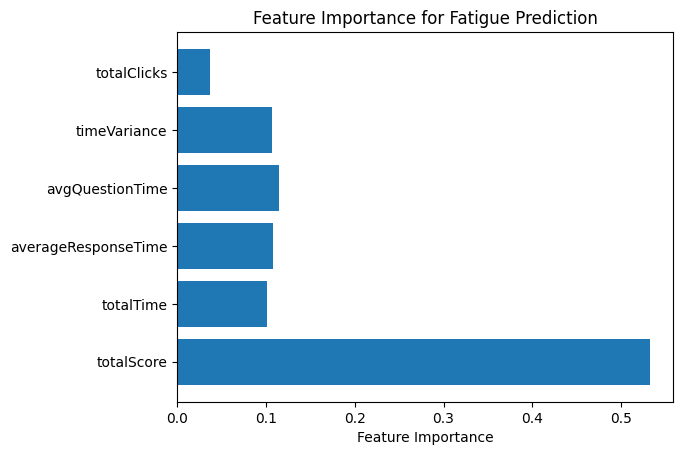

In [17]:
rf_model = RandomForestClassifier(n_estimators=200)
rf_model.fit(X_train, y_train)

importances = rf_model.feature_importances_

features = X.columns

plt.barh(features, importances)

plt.xlabel("Feature Importance")

plt.title("Feature Importance for Fatigue Prediction")

plt.show()